# Task 2: Exploratory Data Analysis
## Financial Inclusion in Ethiopia

This notebook analyzes patterns in Ethiopia's financial inclusion dataset,
covering Access (account ownership), Usage (digital payments), infrastructure
enablers, and event-indicator relationships.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load and Prepare Data

In [3]:
DATA_PATH = "../data/raw/ethiopia_fi_unified_data.xlsx"

main = pd.read_excel(DATA_PATH, sheet_name="ethiopia_fi_unified_data")
impact = pd.read_excel(DATA_PATH, sheet_name="Impact_sheet")

if "parent_id" not in main.columns:
    main.insert(1, "parent_id", pd.NA)
impact = impact[main.columns]

data = pd.concat([main, impact], ignore_index=True)
data["observation_date"] = pd.to_datetime(data["observation_date"], errors="coerce")

print(f"Total records: {len(data)}")
data.head()

Total records: 65


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,<NA>,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,<NA>,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,<NA>,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,<NA>,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,<NA>,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


## 2. Dataset Overview

Summary by record type, pillar, source type, and confidence level.

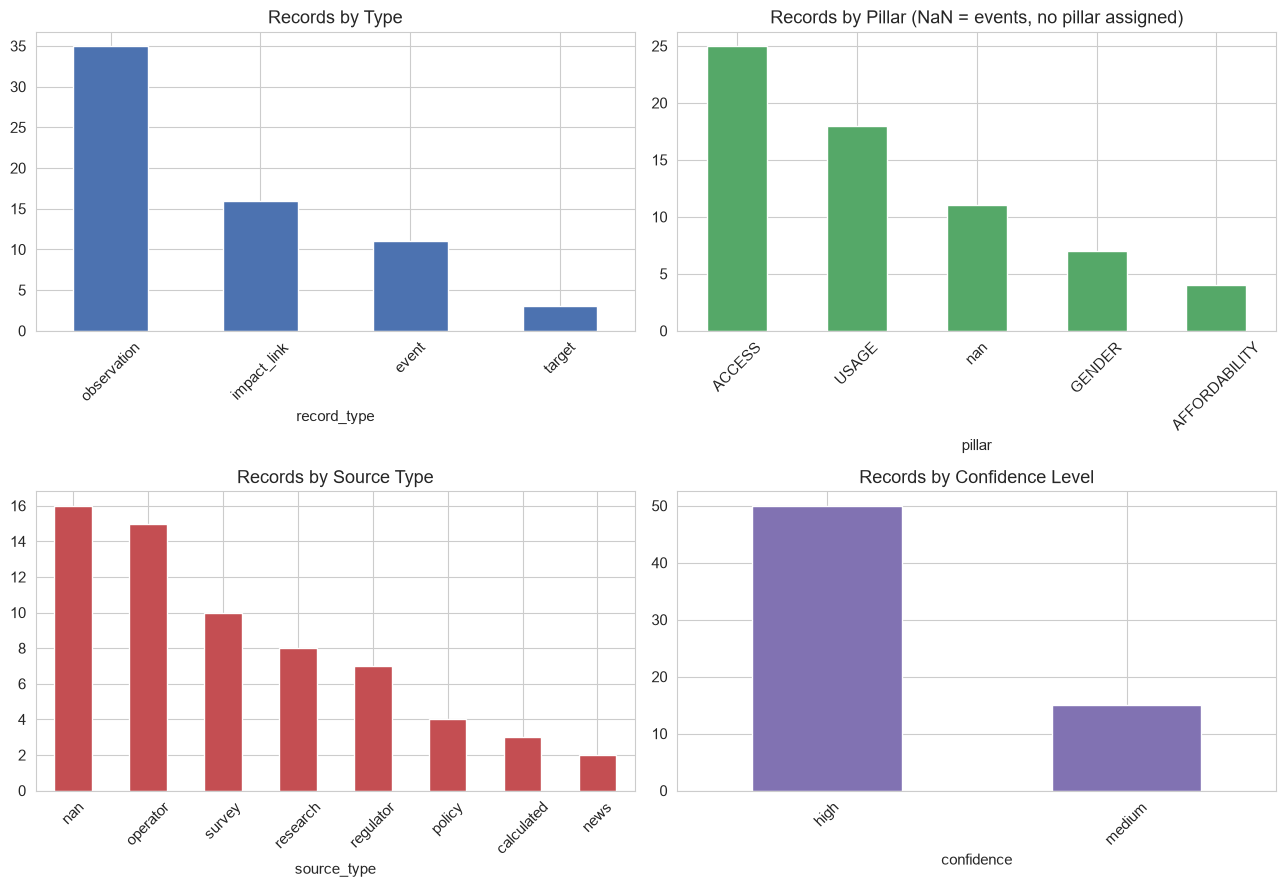

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

data['record_type'].value_counts().plot(kind='bar', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Records by Type')
axes[0,0].tick_params(axis='x', rotation=45)

data['pillar'].value_counts(dropna=False).plot(kind='bar', ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Records by Pillar (NaN = events, no pillar assigned)')
axes[0,1].tick_params(axis='x', rotation=45)

data['source_type'].value_counts(dropna=False).plot(kind='bar', ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('Records by Source Type')
axes[1,0].tick_params(axis='x', rotation=45)

data['confidence'].value_counts(dropna=False).plot(kind='bar', ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('Records by Confidence Level')
axes[1,1].tick_params(axis='x', rotation=45)

savefig("01_dataset_overview")

**Data quality note:** the dataset is dominated by `high` confidence records
(mostly Findex survey data and operator reports). `medium` confidence records
are largely modeled impact_links based on comparable-country evidence rather
than observed Ethiopian data — this distinction matters when interpreting the
forecasting model in Task 4.

## 3. Temporal Coverage

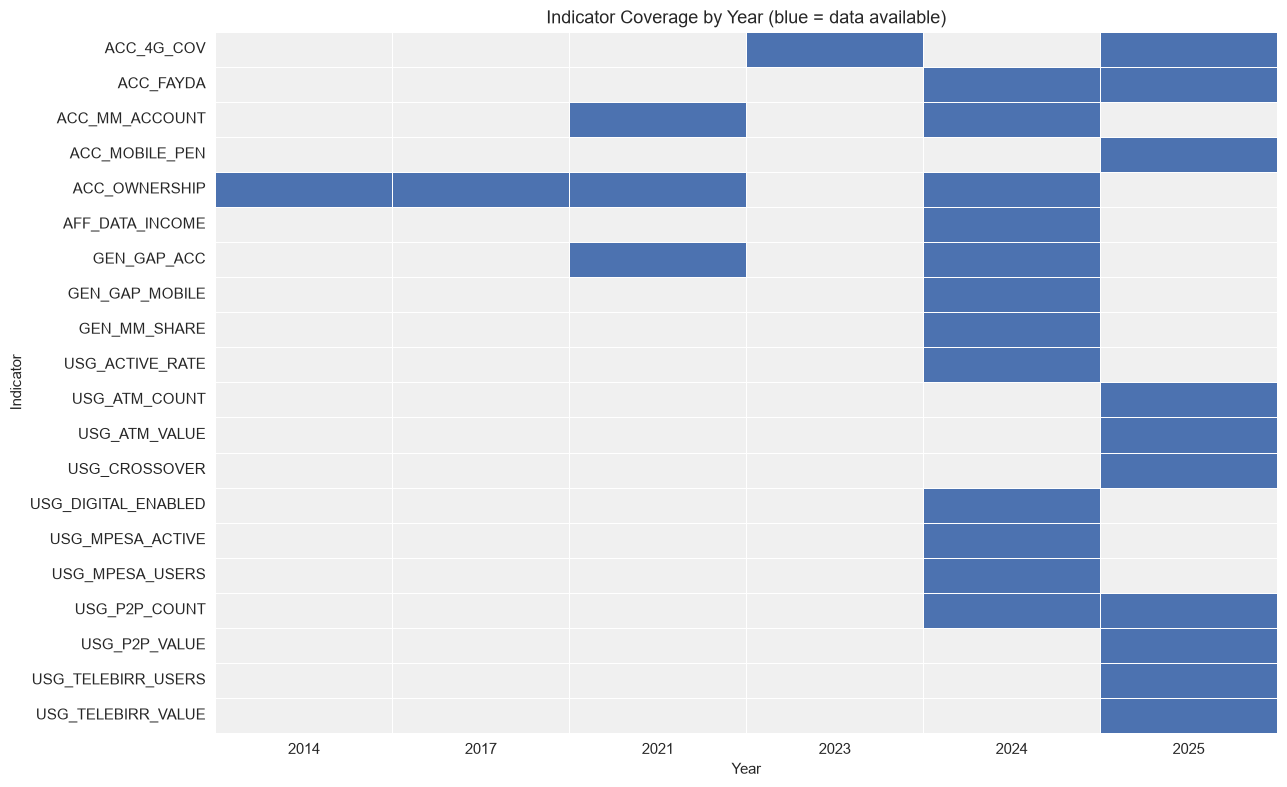

In [5]:
obs = data[data['record_type'] == 'observation'].copy()
obs['year'] = obs['observation_date'].dt.year

coverage = obs.groupby(['indicator_code', 'year']).size().unstack(fill_value=0)
coverage = coverage.sort_index()

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(coverage.gt(0).astype(int), cmap=['#f0f0f0', '#4C72B0'],
            cbar=False, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Indicator Coverage by Year (blue = data available)')
ax.set_xlabel('Year')
ax.set_ylabel('Indicator')
savefig("02_temporal_coverage")

**Gap identified:** most indicators have only 1-2 data points, concentrated
in 2024-2025. Only `ACC_OWNERSHIP` has meaningful historical depth (2014-2024).
This sparsity is the central challenge for forecasting in Task 4 — we cannot
rely on standard time-series methods that need many historical points.

## 4. Access Analysis

### 4.1 Account Ownership Trajectory (2011-2024)

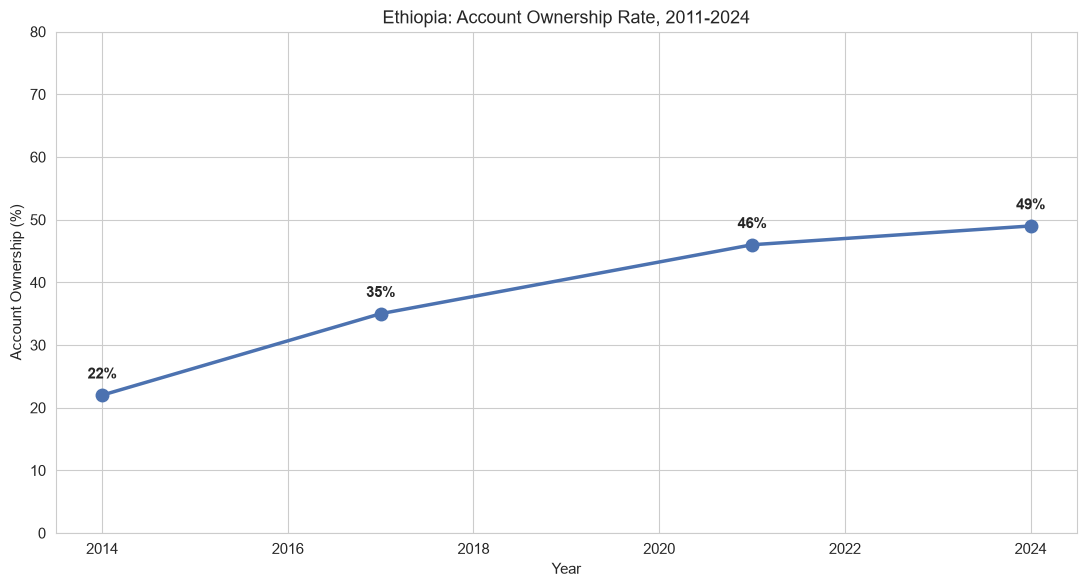

 year  value_numeric  pp_change  pp_per_year
 2014           22.0        NaN          NaN
 2017           35.0       13.0     4.333333
 2021           46.0       11.0     2.750000
 2024           49.0        3.0     1.000000


In [6]:
acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all') & (obs['location'] == 'national')].sort_values('year')

fig, ax = plt.subplots()
ax.plot(acc['year'], acc['value_numeric'], marker='o', linewidth=2.5, markersize=9, color='#4C72B0')
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row['year'], row['value_numeric']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold')
ax.set_title('Ethiopia: Account Ownership Rate, 2011-2024')
ax.set_xlabel('Year')
ax.set_ylabel('Account Ownership (%)')
ax.set_ylim(0, 80)
savefig("03_account_ownership_trajectory")

# Growth rates between survey years
acc = acc.reset_index(drop=True)
acc['pp_change'] = acc['value_numeric'].diff()
acc['years_elapsed'] = acc['year'].diff()
acc['pp_per_year'] = acc['pp_change'] / acc['years_elapsed']
print(acc[['year', 'value_numeric', 'pp_change', 'pp_per_year']].to_string(index=False))

### 4.2 Gender Gap in Account Ownership

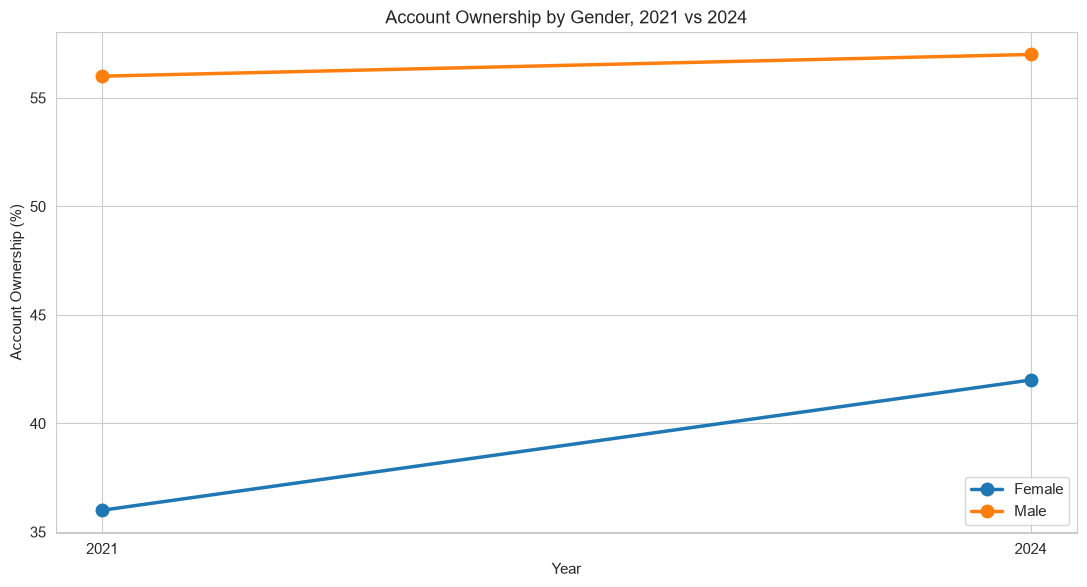

gender  female  male  gap_pp
year                        
2021      36.0  56.0    20.0
2024      42.0  57.0    15.0


In [7]:
gender_acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'].isin(['male', 'female']))].sort_values('year')

fig, ax = plt.subplots()
for gender, group in gender_acc.groupby('gender'):
    ax.plot(group['year'], group['value_numeric'], marker='o', linewidth=2.5,
            markersize=9, label=gender.capitalize())
ax.set_title('Account Ownership by Gender, 2021 vs 2024')
ax.set_xlabel('Year')
ax.set_ylabel('Account Ownership (%)')
ax.legend()
ax.set_xticks(gender_acc['year'].unique())
savefig("04_gender_gap_trend")

gap = gender_acc.pivot(index='year', columns='gender', values='value_numeric')
gap['gap_pp'] = gap['male'] - gap['female']
print(gap)

**Insight:** the gender gap narrowed only slightly, from 20pp (2021) to
15pp (2024, recomputed from disaggregated male/female figures added during
enrichment). Both male and female ownership rose, but not fast enough to close
the gap meaningfully — this tracks with global Findex commentary that mobile
money growth has not been gender-neutral in Ethiopia.

### 4.3 Urban Account Ownership (2024)

location  value_numeric
national           49.0
   urban           73.0


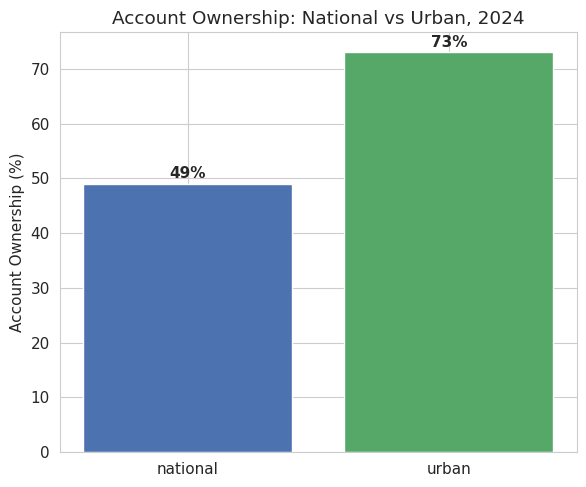

In [7]:
urban_national = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') &
                      (obs['year'] == 2024) &
                      (obs['gender'] == 'all')][['location', 'value_numeric']]
print(urban_national.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(urban_national['location'], urban_national['value_numeric'], color=['#4C72B0', '#55A868'])
ax.set_title('Account Ownership: National vs Urban, 2024')
ax.set_ylabel('Account Ownership (%)')
for i, v in enumerate(urban_national['value_numeric']):
    ax.text(i, v + 1, f"{v:.0f}%", ha='center', fontweight='bold')
savefig("05_urban_vs_national")

**Insight:** urban account ownership (73%) is dramatically higher than the
national average (49%), implying rural ownership is likely well below 49% —
a wide urban-rural divide that the aggregate national figure masks. (No direct
rural observation exists yet; this is flagged as a data gap.)

## 5. Usage (Digital Payments) Analysis

### 5.1 Mobile Money Account Penetration

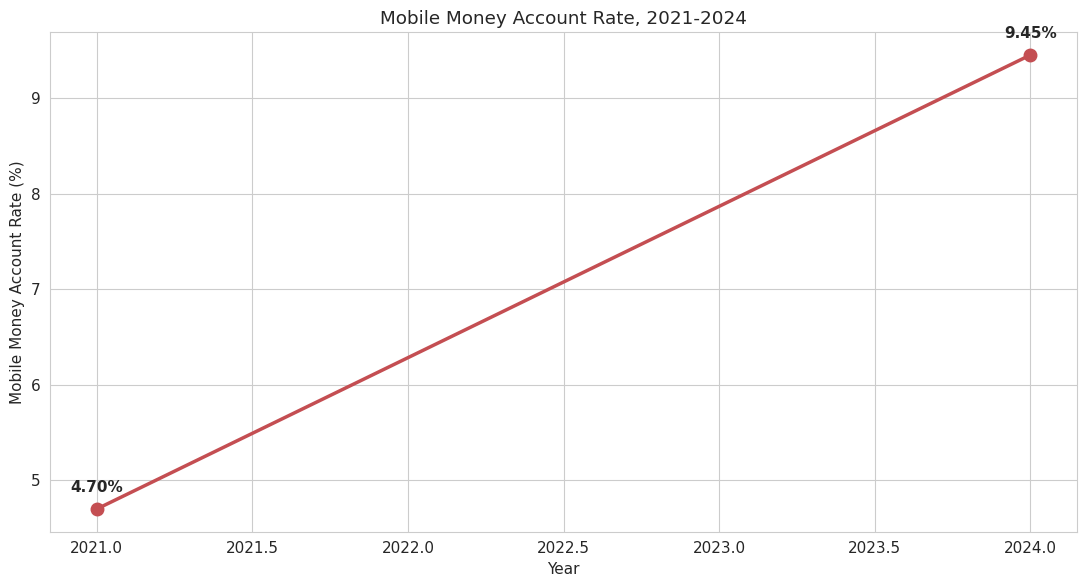

In [8]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('year')
fig, ax = plt.subplots()
ax.plot(mm['year'], mm['value_numeric'], marker='o', linewidth=2.5, markersize=9, color='#C44E52')
for _, row in mm.iterrows():
    ax.annotate(f"{row['value_numeric']:.2f}%", (row['year'], row['value_numeric']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold')
ax.set_title('Mobile Money Account Rate, 2021-2024')
ax.set_xlabel('Year'); ax.set_ylabel('Mobile Money Account Rate (%)')
savefig("06_mobile_money_penetration")

### 5.2 The Registered-vs-Active Gap (M-Pesa)

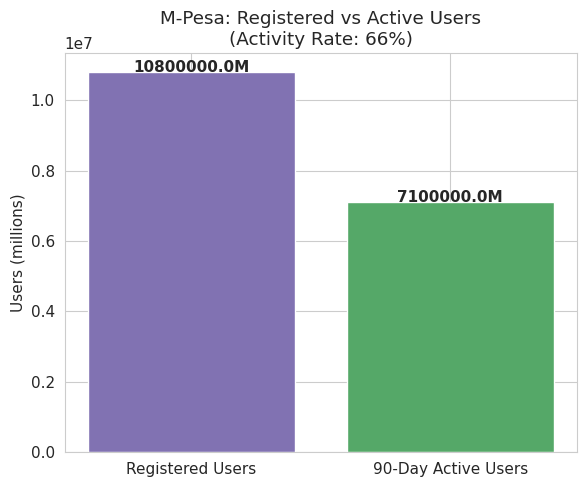

In [9]:
mpesa_reg = obs[obs['indicator_code'] == 'USG_MPESA_USERS']['value_numeric'].values[0]
mpesa_active = obs[obs['indicator_code'] == 'USG_MPESA_ACTIVE']['value_numeric'].values[0]
active_rate = obs[obs['indicator_code'] == 'USG_ACTIVE_RATE']['value_numeric'].values[0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Registered Users', '90-Day Active Users'], [mpesa_reg, mpesa_active],
       color=['#8172B2', '#55A868'])
ax.set_title(f'M-Pesa: Registered vs Active Users\n(Activity Rate: {active_rate:.0f}%)')
ax.set_ylabel('Users (millions)')
for i, v in enumerate([mpesa_reg, mpesa_active]):
    ax.text(i, v + 0.2, f"{v:.1f}M", ha='center', fontweight='bold')
savefig("07_registered_vs_active")

**Insight:** only 66% of M-Pesa's registered users are 90-day active. This
registered-vs-active gap is a recurring theme in the Market Nuances guide —
account *opening* significantly outpaces genuine *usage*, which is exactly why
Access (49%) and Usage (~35% making/receiving digital payments) diverge so much.

### 5.3 P2P vs ATM Crossover

In [ ]:
crossover_data = obs[obs['indicator_code'].isin(['USG_P2P_COUNT', 'USG_ATM_COUNT'])].copy()
crossover_data['label'] = crossover_data['indicator_code'].map({
    'USG_P2P_COUNT': 'P2P Transfers', 'USG_ATM_COUNT': 'ATM Withdrawals'
})
crossover_data['fy_label'] = 'FY' + crossover_data['year'].astype(str)

fig, ax = plt.subplots()
sns.barplot(data=crossover_data, x='fy_label', y='value_numeric', hue='label', ax=ax)
ax.set_title('P2P Digital Transfers vs ATM Cash Withdrawals by Fiscal Year')
ax.set_xlabel('Fiscal Year'); ax.set_ylabel('Transaction Count')
ax.legend(title='')
savefig("08_p2p_atm_crossover")

## 6. Event Timeline and Overlay Analysis

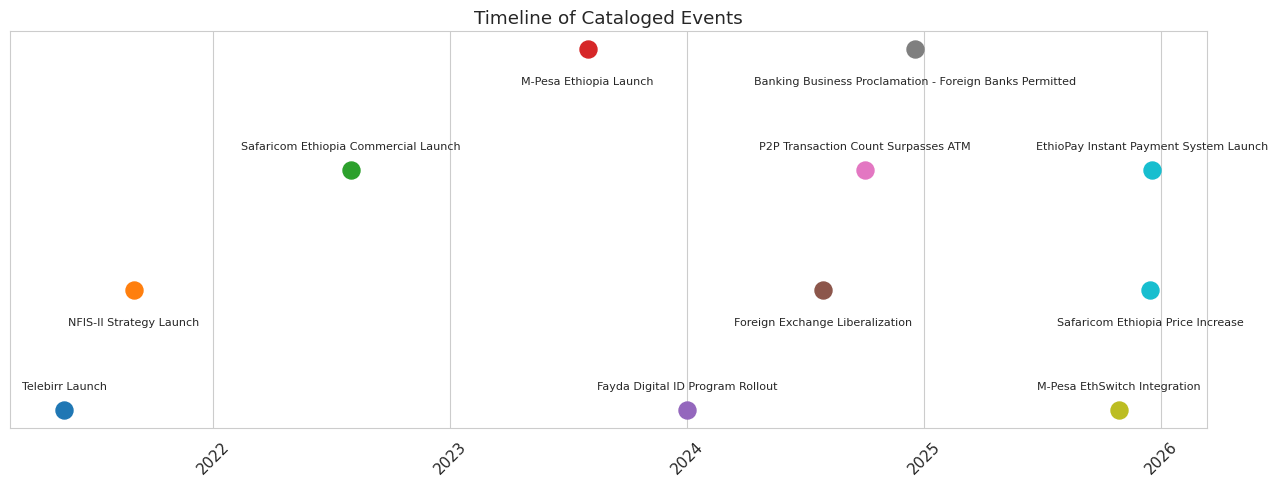

In [11]:
events = data[data['record_type'] == 'event'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(13, 5))
y_positions = np.arange(len(events)) % 4
colors = plt.cm.tab10(np.linspace(0, 1, len(events)))

for i, (_, row) in enumerate(events.iterrows()):
    ax.scatter(row['observation_date'], y_positions[i], s=150, color=colors[i], zorder=3)
    ax.annotate(row['indicator'], (row['observation_date'], y_positions[i]),
                textcoords="offset points", xytext=(0, 15 if y_positions[i] % 2 == 0 else -25),
                ha='center', fontsize=8, rotation=0, wrap=True)

ax.set_yticks([])
ax.set_title('Timeline of Cataloged Events')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45)
savefig("09_event_timeline")

### Overlay: Events on Account Ownership Trend

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.plot(acc['year'], acc['value_numeric'], marker='o', linewidth=2.5,
        markersize=9, color='#4C72B0', zorder=3, label='Account Ownership')

key_events = {
    'EVT_0001': 'Telebirr Launch',
    'EVT_0002': 'Safaricom Entry',
    'EVT_0003': 'M-Pesa Launch',
    'EVT_0004': 'Fayda ID Rollout',
    'EVT_0009': 'NFIS-II Launch',
}
matched = events[events['record_id'].isin(key_events.keys())].copy()
matched['yr'] = matched['observation_date'].dt.year

label_heights = {}
for _, row in matched.iterrows():
    yr = row['yr']
    ax.axvline(yr, color='gray', linestyle='--', alpha=0.5)
    height = 78 - label_heights.get(yr, 0) * 8
    label_heights[yr] = label_heights.get(yr, 0) + 1
    ax.text(yr + 0.05, height, key_events[row['record_id']], rotation=90,
            fontsize=8, ha='left', va='top')

ax.set_title('Account Ownership vs Key Events')
ax.set_xlabel('Year'); ax.set_ylabel('Account Ownership (%)')
ax.set_ylim(0, 85)
savefig("10_events_overlay_ownership")

**Visual observations:**
- Account ownership rose only 3pp (46%→49%) between the 2021 survey (just after
  Telebirr's May 2021 launch) and the 2024 survey — despite Telebirr, M-Pesa,
  and NFIS-II all launching in this window. This supports the "registered ≠
  new-to-system" hypothesis from the Market Nuances guide: most new mobile
  money accounts likely belonged to people who already had bank accounts.
- The 2024 survey excluded Amhara, Tigray, Harari, and Somali — roughly 30%
  of Ethiopia's population — which likely biases the 49% figure and makes
  the 2021→2024 comparison imperfect, not a clean before/after test.

## 7. Correlation and Impact Link Analysis

In [13]:
links_summary = impact[['parent_id', 'related_indicator', 'impact_direction',
                          'impact_magnitude', 'lag_months', 'evidence_basis']].copy()
event_names = events.set_index('record_id')['indicator'].to_dict()
links_summary['event_name'] = links_summary['parent_id'].map(event_names)
links_summary = links_summary[['event_name', 'related_indicator', 'impact_direction',
                                 'impact_magnitude', 'lag_months', 'evidence_basis']]
print(links_summary.to_string(index=False))

                                             event_name  related_indicator impact_direction impact_magnitude  lag_months evidence_basis
                                        Telebirr Launch      ACC_OWNERSHIP         increase             high          12     literature
                                        Telebirr Launch USG_TELEBIRR_USERS         increase             high           3      empirical
                                        Telebirr Launch      USG_P2P_COUNT         increase             high           6      empirical
                   Safaricom Ethiopia Commercial Launch         ACC_4G_COV         increase           medium          12      empirical
                   Safaricom Ethiopia Commercial Launch    AFF_DATA_INCOME         decrease           medium          12     literature
                                 M-Pesa Ethiopia Launch    USG_MPESA_USERS         increase             high           3      empirical
                                 M-Pesa Ethiopia

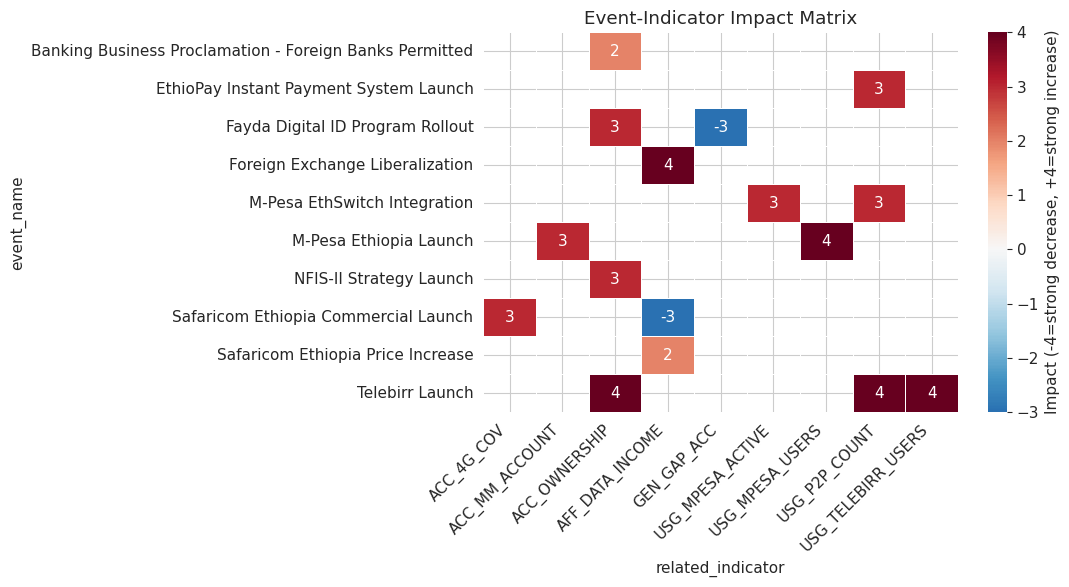

In [14]:
magnitude_map = {'negligible': 1, 'low': 2, 'medium': 3, 'high': 4}
links_summary['magnitude_score'] = links_summary['impact_magnitude'].map(magnitude_map)
links_summary.loc[links_summary['impact_direction'] == 'decrease', 'magnitude_score'] *= -1

pivot = links_summary.pivot_table(index='event_name', columns='related_indicator',
                                    values='magnitude_score', aggfunc='first')

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Impact (-4=strong decrease, +4=strong increase)'}, ax=ax)
ax.set_title('Event-Indicator Impact Matrix')
plt.xticks(rotation=45, ha='right')
savefig("11_event_indicator_matrix")

**Insight:** most impact_links point to `ACC_OWNERSHIP` and `AFF_DATA_INCOME`,
meaning our modeled event effects are concentrated on just two indicators.
Several indicators (e.g. `USG_TELEBIRR_VALUE`, `USG_CROSSOVER`, `GEN_MM_SHARE`)
have zero modeled impact_links — a gap worth addressing in Task 3's impact
modeling, or explicitly flagging as unmodeled.

## 8. Key Insights Summary

1. **Account ownership growth has decelerated sharply**: +8pp (2011-14),
   +13pp (2014-17), +11pp (2017-21), but only **+3pp (2021-24)** — despite
   the launch of Telebirr, M-Pesa, and NFIS-II all occurring in this window.
   This is the central puzzle the assignment asks us to explain.

2. **Registered accounts vastly outpace active accounts**: M-Pesa has 10.8M
   registered users but only 7.1M (66%) are 90-day active, suggesting a
   meaningful chunk of "growth" is dormant or duplicate accounts rather than
   newly-included people.

3. **Urban-rural divide is stark but under-measured**: urban ownership (73%)
   is 24pp above the national average (49%), implying rural ownership is
   substantially lower — yet no direct rural observation exists in the
   dataset, a genuine data gap.

4. **Gender gap narrowed only modestly**: 20pp (2021) → 15pp (2024). Female
   mobile money account share is just 14%, far from parity — the NFIS-II
   parity target (50% by 2030) looks very ambitious given current trajectory.

5. **The 2024 Findex survey excluded ~30% of the population** (Amhara,
   Tigray, Harari, Somali regions), which likely means the reported 49%
   national figure understates true uncertainty and makes 2021→2024
   comparisons imperfect rather than a clean natural experiment.

6. **P2P transfers surpassed ATM withdrawals for the first time** in FY2024/25
   (128.3M vs 119.3M transactions) — a genuine usage milestone, though it
   reflects transaction *volume* shifting to digital rails more than it
   reflects new *account* inclusion.

### Data gaps limiting this analysis
- No rural-specific account ownership figure (only inferable from the
  urban/national gap)
- Most indicators have only 1-2 historical data points — insufficient for
  standard time-series forecasting, motivating the event-augmented approach
  planned for Task 4
- Impact links are concentrated on ACC_OWNERSHIP and AFF_DATA_INCOME; several
  Usage-pillar indicators have no modeled event effects yet

### Hypotheses for Task 3 (Impact Modeling)
- Telebirr/M-Pesa launches drove *usage* growth (transactions, registered
  users) far more than they drove *access* growth (net-new account holders)
- The urban-rural and gender gaps may be better explained by infrastructure
  and identity-document access (4G coverage, Fayda ID) than by product
  launches alone
